In [1]:
# ==========================================
# Laboratorio 7 - Deep Learning con PyTorch
# ==========================================

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

PyTorch: 2.14.1
CUDA disponible: False


# 1. Redes multicapa con `nn.Module`

En esta sección se implementa un perceptrón multicapa (MLP) utilizando PyTorch para resolver el problema XOR. Este problema es un ejemplo clásico que demuestra la necesidad de utilizar capas ocultas y funciones de activación no lineales, ya que un perceptrón simple no puede separar correctamente las clases.

In [2]:
# Datos del problema XOR

X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.]
])

print("Entradas:")
print(X)

print("\nEtiquetas:")
print(y)

Entradas:
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])

Etiquetas:
tensor([[0.],
        [1.],
        [1.],
        [0.]])


In [3]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.hidden = nn.Linear(2, 4)
        self.relu = nn.ReLU()
        self.output = nn.Linear(4, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x


model = MLP()

print(model)

MLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=4, out_features=1, bias=True)
)


### Entrenamiento del modelo

Se entrena el MLP utilizando el conjunto de datos XOR para aprender la relación entre las entradas y sus etiquetas.

In [4]:
# Función de pérdida y optimizador
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Número de épocas
epochs = 5000

# Lista para guardar la pérdida
loss_history = []

# Entrenamiento
for epoch in range(epochs):

    # Forward
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Guardar pérdida
    loss_history.append(loss.item())

    # Mostrar avance cada 500 épocas
    if (epoch + 1) % 500 == 0:
        print(f"Época {epoch+1}/{epochs} - Pérdida: {loss.item():.4f}")

Época 500/5000 - Pérdida: 0.3076
Época 1000/5000 - Pérdida: 0.0436
Época 1500/5000 - Pérdida: 0.0164
Época 2000/5000 - Pérdida: 0.0093
Época 2500/5000 - Pérdida: 0.0062
Época 3000/5000 - Pérdida: 0.0046
Época 3500/5000 - Pérdida: 0.0036
Época 4000/5000 - Pérdida: 0.0030
Época 4500/5000 - Pérdida: 0.0025
Época 5000/5000 - Pérdida: 0.0021


### Curva de pérdida

Se grafica la pérdida durante el entrenamiento para observar cómo aprende el modelo.

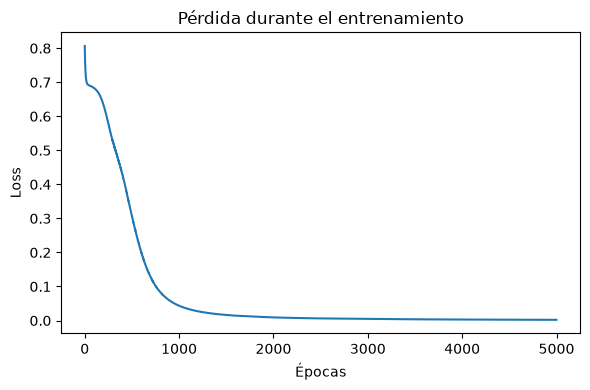

In [7]:
# Gráfica de la pérdida

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.tight_layout()

plt.show()

### Evaluación del modelo

Se realizan las predicciones del modelo sobre el conjunto XOR y se calcula la exactitud obtenida.

In [6]:
# Evaluación
with torch.no_grad():

    logits = model(X)

    predictions = (torch.sigmoid(logits) >= 0.5).float()

    accuracy = (predictions == y).float().mean()

print("Predicciones:")
print(predictions)

print(f"\nExactitud: {accuracy.item()*100:.2f}%")

Predicciones:
tensor([[0.],
        [1.],
        [1.],
        [0.]])

Exactitud: 100.00%


### Análisis

La pérdida disminuyó de forma constante durante el entrenamiento hasta acercarse a cero. Al finalizar, el modelo clasificó correctamente los cuatro casos del problema XOR, alcanzando una exactitud del 100%.

### Frontera de decisión

Se visualiza la frontera de decisión aprendida por el modelo para el problema XOR.

In [8]:
# Crear una malla de puntos

x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Convertir la malla a tensor
grid = torch.tensor(
    np.c_[xx.ravel(), yy.ravel()],
    dtype=torch.float32
)

# Obtener las predicciones del modelo
with torch.no_grad():
    logits = model(grid)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()

Z = preds.numpy().reshape(xx.shape)

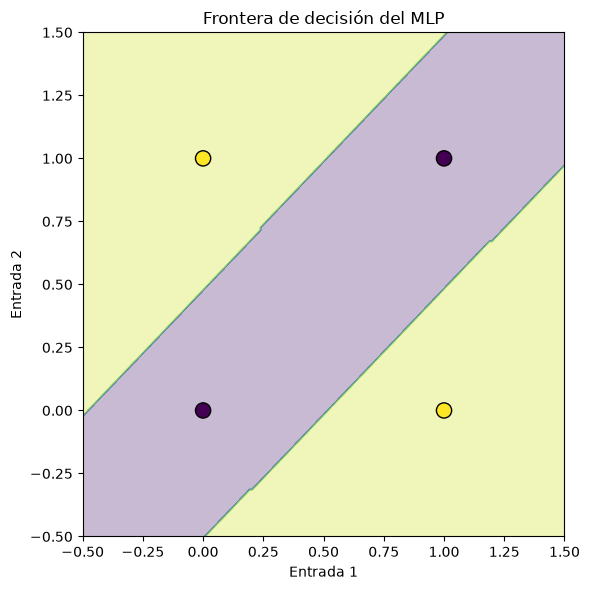

In [9]:
# Graficar la frontera de decisión

plt.figure(figsize=(6,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y.squeeze(),
    s=120,
    edgecolors="black"
)

plt.title("Frontera de decisión del MLP")
plt.xlabel("Entrada 1")
plt.ylabel("Entrada 2")

plt.tight_layout()
plt.show()

### Modelo sin función de activación

Se crea una segunda versión del modelo eliminando la función de activación para comparar su desempeño con el MLP anterior.

In [10]:
# Modelo sin función de activación

class LinearMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = self.output(x)
        return x


linear_model = LinearMLP()

print(linear_model)

LinearMLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
)


In [11]:
# Función de pérdida y optimizador

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(linear_model.parameters(), lr=0.1)

epochs = 5000

loss_history_linear = []

# Entrenamiento
for epoch in range(epochs):

    outputs = linear_model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history_linear.append(loss.item())

### Evaluación del modelo lineal

Se evalúa el modelo sin activación para comparar su capacidad de resolver el problema XOR.

In [12]:
# Evaluación

with torch.no_grad():

    logits = linear_model(X)

    predictions = (torch.sigmoid(logits) >= 0.5).float()

    accuracy = (predictions == y).float().mean()

print("Predicciones:")
print(predictions)

print(f"\nExactitud: {accuracy.item()*100:.2f}%")

Predicciones:
tensor([[0.],
        [1.],
        [0.],
        [1.]])

Exactitud: 50.00%


### Comparación de la pérdida

Se compara la evolución de la pérdida entre el modelo con ReLU y el modelo sin función de activación.

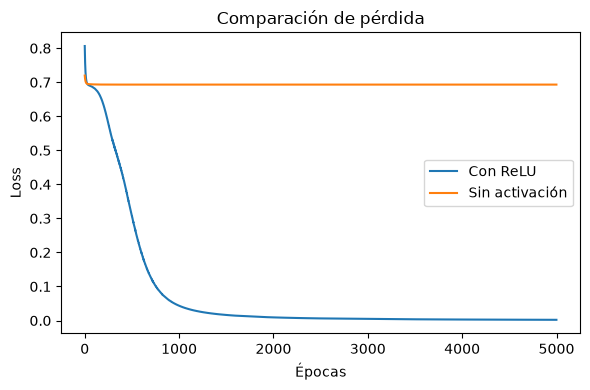

In [13]:
# Comparación de la pérdida

plt.figure(figsize=(6,4))

plt.plot(loss_history, label="Con ReLU")
plt.plot(loss_history_linear, label="Sin activación")

plt.title("Comparación de pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()

### Análisis

El modelo con ReLU logró aprender correctamente el problema XOR, mientras que el modelo sin función de activación no pudo hacerlo y obtuvo una exactitud del 50%. Esto ocurre porque varias capas lineales siguen representando una única transformación lineal, por lo que no pueden aprender una frontera de decisión no lineal.

### Red multicapa 3 → 4 → 4 → 2

Se construye la arquitectura indicada en el laboratorio para identificar sus capas y contar el número de parámetros entrenables.

In [14]:
# Red multicapa 3 -> 4 -> 4 -> 2

class MultiLayerNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 2)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x


network = MultiLayerNetwork()

print(network)

MultiLayerNetwork(
  (fc1): Linear(in_features=3, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)


### Conteo de parámetros

Se calcula la cantidad total de parámetros entrenables de la red.

In [15]:
# Contar parámetros entrenables

total_params = sum(param.numel() for param in network.parameters())

print(f"Total de parámetros: {total_params}")

Total de parámetros: 46


In [16]:
# Mostrar nombre y forma de cada parámetro

for name, param in network.named_parameters():
    print(f"{name}: {tuple(param.shape)}")

fc1.weight: (4, 3)
fc1.bias: (4,)
fc2.weight: (4, 4)
fc2.bias: (4,)
fc3.weight: (2, 4)
fc3.bias: (2,)


### Análisis

La red tiene 46 parámetros entrenables distribuidos entre los pesos y sesgos de sus tres capas lineales. La información mostrada por `named_parameters()` permite identificar la forma de cada tensor y comprender cómo está organizada la arquitectura del modelo.

# 2. Funciones de activación

En esta sección se comparan las funciones de activación Sigmoid, Tanh y ReLU junto con sus derivadas.

In [17]:
# Crear el tensor de entrada

z = torch.linspace(-5, 5, 200, requires_grad=True)

### Cálculo de las funciones

Se calculan las funciones Sigmoid, Tanh y ReLU utilizando PyTorch.

In [18]:
# Funciones de activación

sigmoid = torch.sigmoid(z)
tanh = torch.tanh(z)
relu = torch.relu(z)

### Derivadas con autograd

Se obtienen las derivadas de cada función utilizando el sistema de diferenciación automática de PyTorch.

In [19]:
# Derivada de Sigmoid

sigmoid_grad = torch.autograd.grad(
    outputs=sigmoid,
    inputs=z,
    grad_outputs=torch.ones_like(sigmoid),
    create_graph=False
)[0]

# Derivada de Tanh

tanh_grad = torch.autograd.grad(
    outputs=tanh,
    inputs=z,
    grad_outputs=torch.ones_like(tanh),
    create_graph=False
)[0]

# Derivada de ReLU

relu_grad = torch.autograd.grad(
    outputs=relu,
    inputs=z,
    grad_outputs=torch.ones_like(relu),
    create_graph=False
)[0]

### Comparación de funciones y derivadas

Se muestran las funciones de activación y sus derivadas en una misma figura.

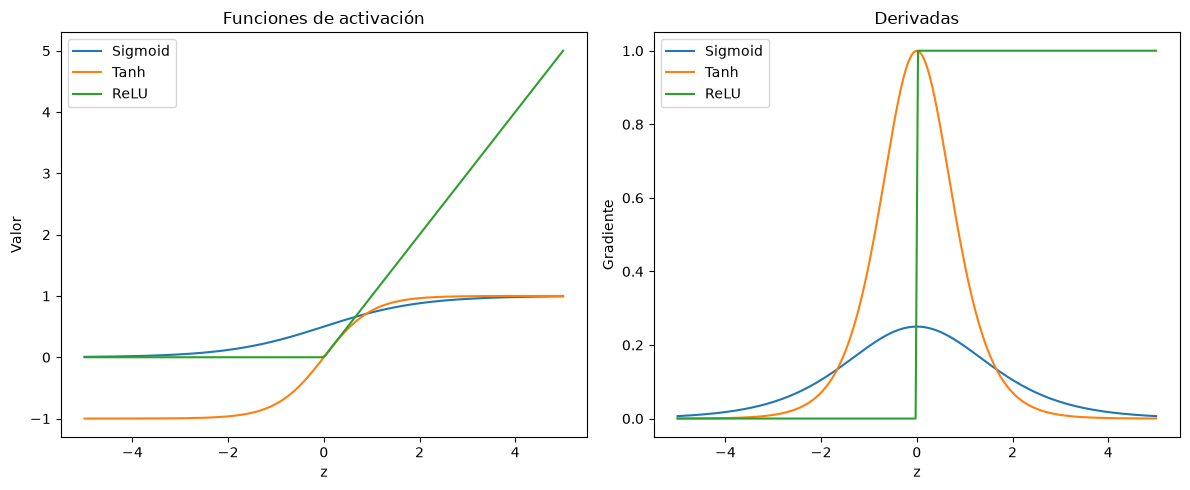

In [20]:
# Crear la figura

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Funciones
axes[0].plot(z.detach(), sigmoid.detach(), label="Sigmoid")
axes[0].plot(z.detach(), tanh.detach(), label="Tanh")
axes[0].plot(z.detach(), relu.detach(), label="ReLU")

axes[0].set_title("Funciones de activación")
axes[0].set_xlabel("z")
axes[0].set_ylabel("Valor")
axes[0].legend()

# Derivadas
axes[1].plot(z.detach(), sigmoid_grad.detach(), label="Sigmoid")
axes[1].plot(z.detach(), tanh_grad.detach(), label="Tanh")
axes[1].plot(z.detach(), relu_grad.detach(), label="ReLU")

axes[1].set_title("Derivadas")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Gradiente")
axes[1].legend()

plt.tight_layout()
plt.show()

### Análisis

La sigmoide y la función tanh presentan un gradiente muy pequeño cuando los valores de entrada son muy negativos o muy positivos, lo que dificulta el aprendizaje en esas regiones. En cambio, ReLU mantiene un gradiente constante para los valores positivos, permitiendo un entrenamiento más estable y rápido, por lo que suele utilizarse como función de activación en las capas ocultas.

# 3. Pérdida, optimizador y ciclo de entrenamiento

En esta sección se entrena un perceptrón multicapa utilizando el conjunto de datos Iris para clasificar sus tres especies.

In [21]:
# Librerías para trabajar con el conjunto Iris

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
# Cargar el conjunto de datos

iris = load_iris()

X = iris.data
y = iris.target

print("Número de muestras:", X.shape[0])
print("Número de características:", X.shape[1])
print("Número de clases:", len(np.unique(y)))

Número de muestras: 150
Número de características: 4
Número de clases: 3


In [23]:
# Dividir en entrenamiento (80%) y validación (20%)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
# Estandarizar las características

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [25]:
# Convertir los datos a tensores

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [26]:
# Verificar las dimensiones

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)

print("Etiquetas de entrenamiento:", y_train.shape)
print("Etiquetas de validación:", y_val.shape)

Entrenamiento: torch.Size([120, 4])
Validación: torch.Size([30, 4])
Etiquetas de entrenamiento: torch.Size([120])
Etiquetas de validación: torch.Size([30])


### Análisis

El conjunto Iris se dividió de forma estratificada en entrenamiento y validación. Después, las características se estandarizaron utilizando únicamente la información del conjunto de entrenamiento para evitar introducir información del conjunto de validación.

### Modelo MLP

Se define un perceptrón multicapa con cuatro entradas, una capa oculta y tres neuronas de salida, una para cada especie del conjunto Iris.

In [27]:
# Modelo MLP para el conjunto Iris

class IrisMLP(nn.Module):

    def __init__(self):
        super().__init__()

        # Capa de entrada -> capa oculta
        self.hidden = nn.Linear(4, 8)

        # Función de activación
        self.relu = nn.ReLU()

        # Capa oculta -> salida
        self.output = nn.Linear(8, 3)

    def forward(self, x):

        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)

        return x


model = IrisMLP()

print(model)

IrisMLP(
  (hidden): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=8, out_features=3, bias=True)
)


In [28]:
# Contar parámetros entrenables

total_params = sum(param.numel() for param in model.parameters())

print(f"Total de parámetros: {total_params}")

Total de parámetros: 67


In [29]:
# Mostrar la forma de cada parámetro

for name, param in model.named_parameters():
    print(f"{name}: {tuple(param.shape)}")

hidden.weight: (8, 4)
hidden.bias: (8,)
output.weight: (3, 8)
output.bias: (3,)


### Análisis

El modelo cuenta con una capa oculta de ocho neuronas y un total de 67 parámetros entrenables. La salida tiene tres neuronas, una para cada especie del conjunto Iris.

### Entrenamiento del modelo

Se entrena el modelo utilizando la función de pérdida CrossEntropyLoss y el optimizador SGD.

In [30]:
# Función de pérdida y optimizador

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1
)

In [31]:
# Número de épocas

epochs = 200

# Lista para almacenar la pérdida

loss_history = []

In [32]:
# Ciclo de entrenamiento

for epoch in range(epochs):

    # 1. Forward
    outputs = model(X_train)

    # 2. Calcular la pérdida
    loss = criterion(outputs, y_train)

    # 3. Reiniciar gradientes
    optimizer.zero_grad()

    # 4. Backward
    loss.backward()

    # 5. Actualizar parámetros
    optimizer.step()

    # Guardar la pérdida
    loss_history.append(loss.item())

    # Mostrar progreso
    if (epoch + 1) % 20 == 0:
        print(f"Época {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

Época 20/200 - Loss: 1.0534
Época 40/200 - Loss: 0.9120
Época 60/200 - Loss: 0.6053
Época 80/200 - Loss: 0.4467
Época 100/200 - Loss: 0.3696
Época 120/200 - Loss: 0.3170
Época 140/200 - Loss: 0.2740
Época 160/200 - Loss: 0.2368
Época 180/200 - Loss: 0.2051
Época 200/200 - Loss: 0.1789


### Curva de pérdida

Se muestra la evolución de la pérdida durante el entrenamiento.

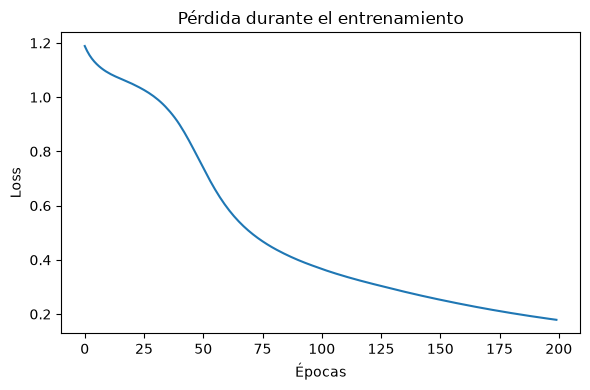

In [33]:
# Graficar la pérdida

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

### ¿Por qué no usar Softmax?

Cuando se utiliza `nn.CrossEntropyLoss`, no es necesario agregar una capa Softmax al final del modelo, ya que esta función la aplica internamente de forma más estable numéricamente.

### Análisis

La pérdida disminuyó de forma progresiva durante el entrenamiento, indicando que el modelo aprendió a clasificar las especies del conjunto Iris. El ciclo de entrenamiento siguió las etapas estándar de PyTorch: forward, cálculo de la pérdida, backward y actualización de los parámetros mediante SGD.

### Comparación de tasas de aprendizaje

Se compara el comportamiento del entrenamiento utilizando diferentes tasas de aprendizaje con el optimizador SGD.

In [56]:
# Función para entrenar el modelo con una tasa de aprendizaje
def train_model(lr):

    torch.manual_seed(42)
    model = IrisMLP()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    epochs = 200
    losses = []

    for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return model, losses

In [64]:
# Entrenar con diferentes tasas de aprendizaje


model_lr_0001, loss_lr_0001 = train_model(0.001)
model_lr_01, loss_lr_01 = train_model(0.1)
model_lr_10, loss_lr_10 = train_model(10)

### Comparación de pérdidas

Se muestran las curvas de pérdida obtenidas con tres tasas de aprendizaje diferentes.

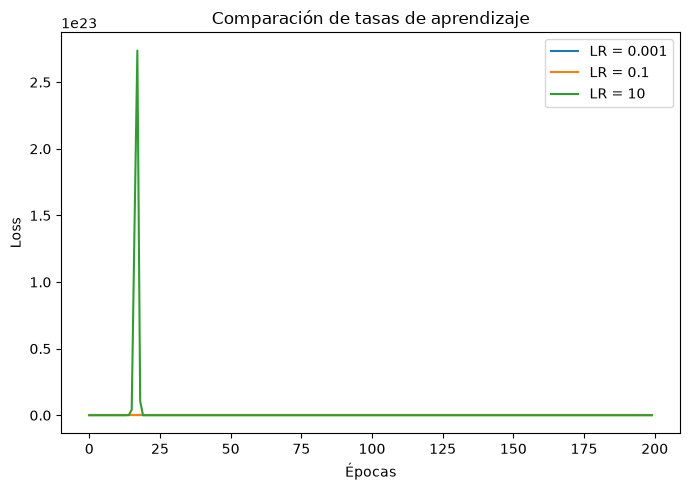

In [65]:
# Comparación de pérdidas

plt.figure(figsize=(7,5))

plt.plot(loss_lr_0001, label="LR = 0.001")
plt.plot(loss_lr_01, label="LR = 0.1")
plt.plot(loss_lr_10, label="LR = 10")

plt.title("Comparación de tasas de aprendizaje")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()

### Análisis

La tasa de aprendizaje de **0.001** reduce la pérdida de forma lenta, por lo que el aprendizaje es más gradual. Con una tasa de **0.1**, el modelo converge de manera estable y obtiene la mejor curva de entrenamiento. En cambio, una tasa de **10** provoca que la pérdida aumente rápidamente, mostrando que el entrenamiento diverge debido a actualizaciones demasiado grandes de los pesos.

### Comparación entre SGD y Adam

Se entrena el mismo modelo utilizando el optimizador Adam y se compara su curva de pérdida con la mejor obtenida usando SGD.

In [59]:
# Función para entrenar utilizando Adam

def train_model_adam():

    torch.manual_seed(42)
    model = IrisMLP()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    epochs = 300
    losses = []

    for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return model, losses

In [60]:
# Entrenar con Adam

adam_model, adam_loss = train_model_adam()

### Comparación de pérdidas

Se comparan las curvas de pérdida obtenidas con SGD y Adam.

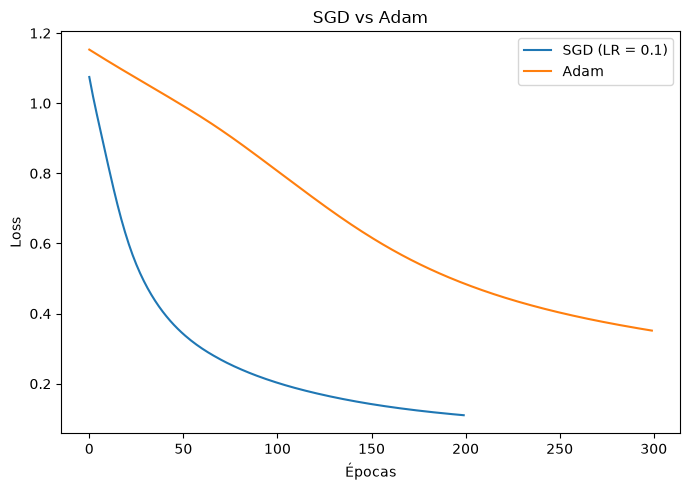

In [48]:
plt.figure(figsize=(7,5))

plt.plot(loss_lr_01, label="SGD (LR = 0.1)")
plt.plot(adam_loss, label="Adam")

plt.title("SGD vs Adam")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()


### Análisis

Tanto **SGD** como **Adam** lograron reducir la pérdida durante el entrenamiento. Sin embargo, en este experimento **SGD con una tasa de aprendizaje de 0.1** presentó una convergencia más rápida y alcanzó una pérdida final menor que Adam. Esto indica que, para esta arquitectura y esta configuración del conjunto Iris, **SGD obtuvo un mejor desempeño**.